# Part 1: Data Audit, EDA & Business Understanding
## D2C Personal Care Brand — Customer Churn Intelligence

**Objective:** Load, audit, and explore all raw datasets. Surface data-quality issues, churn-risk patterns, and business hypotheses to guide retention strategy.

**Author:** ML Engineering Team  
**Dataset:** D2C Churn Dataset Package

---
## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Output directories
os.makedirs('charts', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Color palette
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams['figure.dpi'] = 120
print('Setup complete.')

Setup complete.


---
## 1. Data Loading

Load all files from the `data/` directory. Adjust filenames if your download uses different names.

In [2]:
DATA_DIR = 'data'

# ── helper: load with error reporting ──────────────────────────────────────
def load_csv(filename, **kwargs):
    path = os.path.join(DATA_DIR, filename)
    try:
        df = pd.read_csv(path, **kwargs)
        print(f'✓  {filename:<35} {df.shape[0]:>7,} rows × {df.shape[1]} cols')
        return df
    except FileNotFoundError:
        print(f'✗  {filename} NOT FOUND — check data/ folder')
        return pd.DataFrame()

customers   = load_csv('customers.csv')
orders      = load_csv('orders.csv')
tickets     = load_csv('support_tickets.csv')
events      = load_csv('web_events_snapshot.csv')
churn       = load_csv('churn_labels.csv')
campaigns   = load_csv('intervention_history.csv')
snapshot    = load_csv('rfm_modeling_snapshot.csv')

print('\nAll files loaded.')

✓  customers.csv                         2,400 rows × 9 cols
✓  orders.csv                           10,009 rows × 10 cols
✓  support_tickets.csv                   1,921 rows × 8 cols
✓  web_events_snapshot.csv               2,400 rows × 10 cols
✓  churn_labels.csv                      2,400 rows × 4 cols
✓  intervention_history.csv              2,400 rows × 5 cols
✓  rfm_modeling_snapshot.csv             2,400 rows × 29 cols

All files loaded.


---
## 2. Schema Inspection

In [3]:
datasets = {
    'customers': customers,
    'orders': orders,
    'support_tickets': tickets,
    'web_app_events': events,
    'churn_labels': churn,
    'campaigns': campaigns,
    'modeling_snapshot': snapshot
}

for name, df in datasets.items():
    if df.empty:
        continue
    print(f"\n{'=' * 60}")
    print(f' {name.upper()}')
    print(f"{'='*60}")
    display(df.dtypes.to_frame('dtype').join(
        df.isnull().mean().to_frame('missing_pct').round(3)))
    display(df.head(3))


 CUSTOMERS


,dtype,missing_pct
customer_id,object,0.00
signup_date,object,0.00
city_tier,object,0.00
age_group,object,0.00
acquisition_channel,object,0.00
loyalty_tier,object,0.58
preferred_category,object,0.00
skin_type,object,0.17
marketing_consent,object,0.00


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes



 ORDERS


,dtype,missing_pct
order_id,object,0.00
customer_id,object,0.00
order_date,object,0.00
category,object,0.00
quantity,int64,0.00
gross_amount,float64,0.00
discount_pct,float64,0.00
delivery_days,int64,0.00
returned,int64,0.00
rating,float64,0.01


...

,dtype,missing_pct
customer_id,object,0.00
snapshot_date,object,0.00
last_campaign_received,object,0.00
last_campaign_cost,int64,0.00
manual_priority_bucket,object,0.00


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high



 MODELING_SNAPSHOT


,dtype,missing_pct
customer_id,object,0.00
snapshot_date,object,0.00
city_tier,object,0.00
age_group,object,0.00
acquisition_channel,object,0.00
loyalty_tier,object,0.58
preferred_category,object,0.00
marketing_consent,object,0.00
recency_days,int64,0.00
frequency_180d,int64,0.00


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.00,0.23,3.00,1,0,0.00,0.00,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.00,0.23,4.00,1,1,0.00,1.00,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.00,0.47,2.00,1,0,0.00,0.00,206,1,3,0,0,0,0,0,26,1,train


---
## 3. Data Quality Audit

In [4]:
# ── 3.1 Missing Values Summary ──────────────────────────────────────────────
def missing_summary(df, name):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    result = result[result['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    if not result.empty:
        print(f'\nMissing values in {name}:')
        display(result)
    else:
        print(f'\n{name}: No missing values detected.')
    return result

for name, df in datasets.items():
    if not df.empty:
        missing_summary(df, name)


Missing values in customers:


,missing_count,missing_pct
loyalty_tier,1386,57.75
skin_type,401,16.71



Missing values in orders:


,missing_count,missing_pct
rating,80,0.80



support_tickets: No missing values detected.

web_app_events: No missing values detected.

churn_labels: No missing values detected.

campaigns: No missing values detected.

Missing values in modeling_snapshot:


,missing_count,missing_pct
loyalty_tier,1386,57.75


In [5]:
# ── 3.2 Duplicate Check ──────────────────────────────────────────────────────
print('Duplicate row check:')
for name, df in datasets.items():
    if not df.empty:
        n_dup = df.duplicated().sum()
        print(f'  {name:<30} exact duplicate rows: {n_dup:,}')

# Key-level uniqueness
print('\nKey uniqueness check:')
key_checks = [
    ('customers', 'customer_id'),
    ('orders', 'order_id'),
    ('churn_labels', 'customer_id')
]
for ds_name, key_col in key_checks:
    df = datasets[ds_name]
    if not df.empty and key_col in df.columns:
        n_total = len(df)
        n_unique = df[key_col].nunique()
        print(f'  {ds_name}.{key_col}: {n_unique:,} unique / {n_total:,} rows  →  {"OK" if n_total==n_unique else "⚠ DUPLICATES"}')

Duplicate row check:
  customers                      exact duplicate rows: 0
  orders                         exact duplicate rows: 0
  support_tickets                exact duplicate rows: 0
  web_app_events                 exact duplicate rows: 0
  churn_labels                   exact duplicate rows: 0
  campaigns                      exact duplicate rows: 0
  modeling_snapshot              exact duplicate rows: 0

Key uniqueness check:
  customers.customer_id: 2,400 unique / 2,400 rows  →  OK
  orders.order_id: 10,009 unique / 10,009 rows  →  OK
  churn_labels.customer_id: 2,400 unique / 2,400 rows  →  OK


Order monetary column: gross_amount
count   10009.00
mean      743.90
std       600.56
min       149.00
25%       432.85
50%       597.06
75%       907.43
max     24789.38
Name: gross_amount, dtype: float64


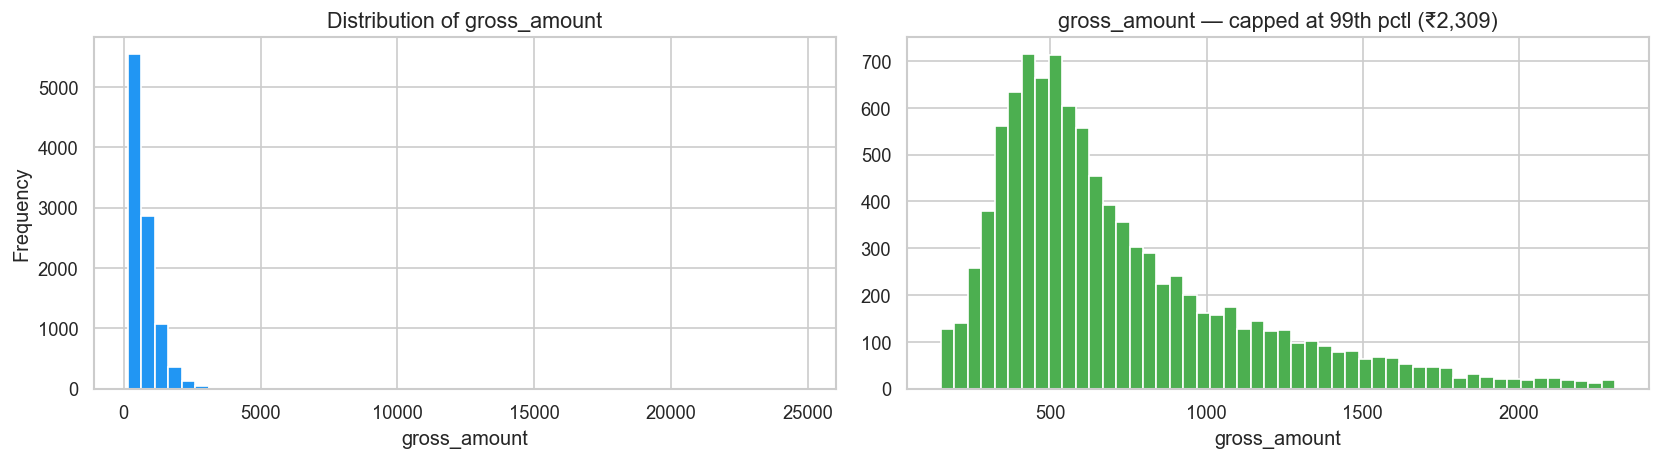


Negative order amounts: 0
Zero order amounts: 0


In [6]:
# ── 3.3 Outlier Check on Order Amounts ───────────────────────────────────────
if not orders.empty:
    # Identify the monetary column (common names)
    amt_col = next((c for c in orders.columns if 'amount' in c.lower() or 'value' in c.lower() or 'revenue' in c.lower()), None)
    
    if amt_col:
        print(f'Order monetary column: {amt_col}')
        print(orders[amt_col].describe())
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        orders[amt_col].hist(bins=50, ax=axes[0], color=PALETTE[0], edgecolor='white')
        axes[0].set_title(f'Distribution of {amt_col}', fontsize=13)
        axes[0].set_xlabel(amt_col)
        axes[0].set_ylabel('Frequency')
        
        # Cap at 99th pct for visibility
        cap = orders[amt_col].quantile(0.99)
        orders[orders[amt_col] <= cap][amt_col].hist(bins=50, ax=axes[1], color=PALETTE[2], edgecolor='white')
        axes[1].set_title(f'{amt_col} — capped at 99th pctl (₹{cap:,.0f})', fontsize=13)
        axes[1].set_xlabel(amt_col)
        
        plt.tight_layout()
        plt.savefig('charts/01_order_amount_distribution.png', bbox_inches='tight')
        plt.show()
        print(f'\nNegative order amounts: {(orders[amt_col] < 0).sum()}')
        print(f'Zero order amounts: {(orders[amt_col] == 0).sum()}')

---
## 4. Dataset Joins & Coverage Analysis

In [7]:
# ── 4.1 Join coverage: customers ↔ churn_labels ──────────────────────────────
if not customers.empty and not churn.empty:
    # Auto-detect customer_id column name
    cust_id_col = next((c for c in customers.columns if 'customer' in c.lower() and 'id' in c.lower()), customers.columns[0])
    churn_id_col = next((c for c in churn.columns if 'customer' in c.lower() and 'id' in c.lower()), churn.columns[0])
    
    cust_ids = set(customers[cust_id_col])
    churn_ids = set(churn[churn_id_col])
    
    in_both = len(cust_ids & churn_ids)
    only_customers = len(cust_ids - churn_ids)
    only_churn = len(churn_ids - cust_ids)
    
    print(f'customers ↔ churn_labels join coverage:')
    print(f'  Matched (in both)       : {in_both:,}')
    print(f'  Only in customers       : {only_customers:,}  (no label — new/unlabeled customers)')
    print(f'  Only in churn_labels    : {only_churn:,}  ← ORPHAN LABELS (investigate!)')

customers ↔ churn_labels join coverage:
  Matched (in both)       : 2,400
  Only in customers       : 0  (no label — new/unlabeled customers)
  Only in churn_labels    : 0  ← ORPHAN LABELS (investigate!)


In [8]:
# ── 4.2 Build master DataFrame ───────────────────────────────────────────────
if not customers.empty and not churn.empty:
    master = customers.merge(churn, on=cust_id_col, how='inner')
    print(f'Master (customers + churn_labels): {master.shape}')
    
    # Order aggregates per customer
    if not orders.empty:
        order_cust_col = next((c for c in orders.columns if 'customer' in c.lower() and 'id' in c.lower()), None)
        if order_cust_col:
            amt_col = next((c for c in orders.columns if 'amount' in c.lower() or 'value' in c.lower() or 'revenue' in c.lower()), None)
            date_col = next((c for c in orders.columns if 'date' in c.lower() or 'time' in c.lower()), None)
            
            agg_dict = {'order_count': (order_cust_col, 'count')}
            if amt_col:
                agg_dict['total_spend'] = (amt_col, 'sum')
                agg_dict['avg_order_value'] = (amt_col, 'mean')
            
            order_agg = orders.groupby(order_cust_col).agg(**agg_dict).reset_index()
            order_agg.rename(columns={order_cust_col: cust_id_col}, inplace=True)
            master = master.merge(order_agg, on=cust_id_col, how='left')
            master['order_count'] = master['order_count'].fillna(0)
            print(f'Master after order join: {master.shape}')
    
    # Support ticket aggregates
    if not tickets.empty:
        ticket_cust_col = next((c for c in tickets.columns if 'customer' in c.lower() and 'id' in c.lower()), None)
        if ticket_cust_col:
            ticket_agg = tickets.groupby(ticket_cust_col).agg(
                ticket_count=(ticket_cust_col, 'count')
            ).reset_index()
            ticket_agg.rename(columns={ticket_cust_col: cust_id_col}, inplace=True)
            master = master.merge(ticket_agg, on=cust_id_col, how='left')
            master['ticket_count'] = master['ticket_count'].fillna(0)
            print(f'Master after ticket join: {master.shape}')
    
    master.to_csv('outputs/merged_master.csv', index=False)
    print('\nSaved outputs/merged_master.csv')
    display(master.head())

Master (customers + churn_labels): (2400, 12)
Master after order join: (2400, 15)
Master after ticket join: (2400, 16)

Saved outputs/merged_master.csv


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,order_count,total_spend,avg_order_value,ticket_count
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,6,2955.57,492.60,2.00
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,3,1713.10,571.03,1.00
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,649.98,649.98,0.00
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,1604.04,1604.04,0.00
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,6,3910.43,651.74,1.00


---
## 5. Churn Distribution Analysis

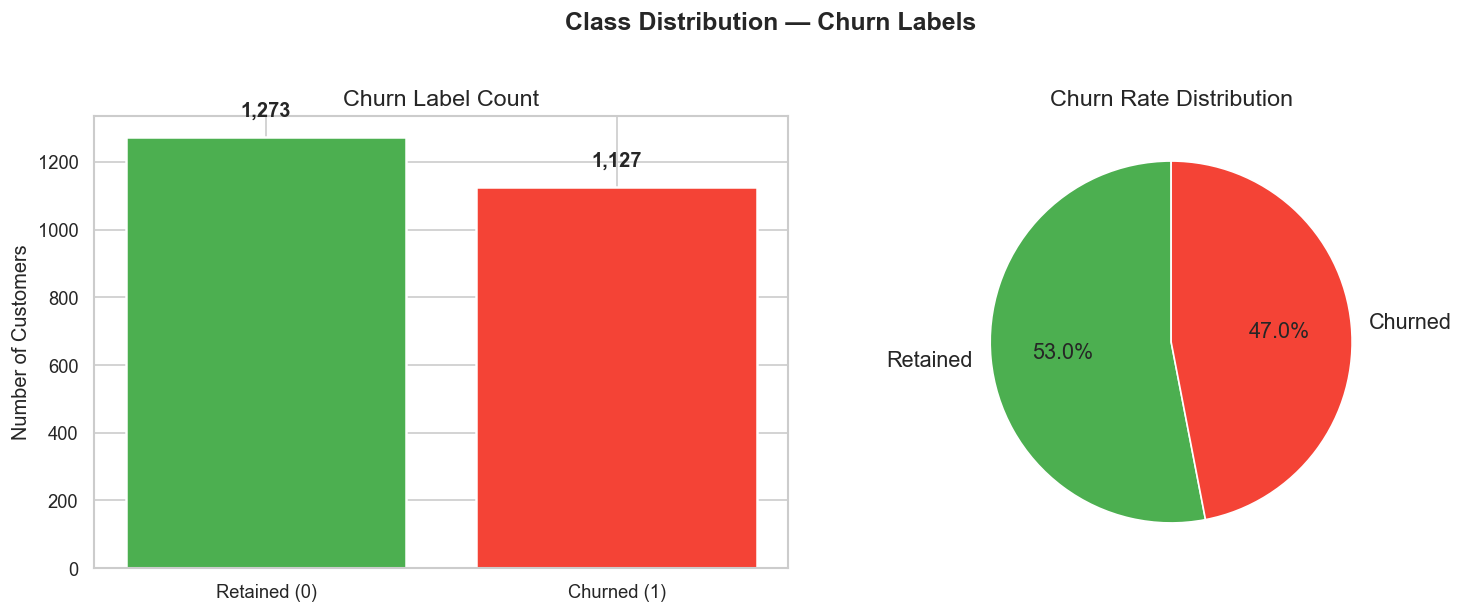

Churned: 47.0%  |  Retained: 53.0%

⚠ Moderate class imbalance present. Model will need weighted training or threshold tuning.


In [9]:
# ── 5.1 Churn label distribution ─────────────────────────────────────────────
if not churn.empty:
    label_col = next((c for c in churn.columns if 'churn' in c.lower() and 'label' in c.lower()), 
                     next((c for c in churn.columns if 'churn' in c.lower()), None))
    
    if label_col:
        churn_counts = churn[label_col].value_counts()
        churn_pct = churn[label_col].value_counts(normalize=True) * 100
        
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        
        # Count bar
        bars = axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values, 
                            color=[PALETTE[2], PALETTE[1]], edgecolor='white', linewidth=1.5)
        for bar, val in zip(bars, churn_counts.values):
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                        f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        axes[0].set_title('Churn Label Count', fontsize=14)
        axes[0].set_ylabel('Number of Customers')
        
        # Pie chart
        axes[1].pie(churn_pct.values, labels=['Retained', 'Churned'], 
                    colors=[PALETTE[2], PALETTE[1]], autopct='%1.1f%%',
                    startangle=90, textprops={'fontsize': 13})
        axes[1].set_title('Churn Rate Distribution', fontsize=14)
        
        plt.suptitle('Class Distribution — Churn Labels', fontsize=15, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('charts/02_churn_distribution.png', bbox_inches='tight')
        plt.show()
        
        print(f'Churned: {churn_pct.get(1, churn_pct.iloc[1]):.1f}%  |  Retained: {churn_pct.get(0, churn_pct.iloc[0]):.1f}%')
        print('\n⚠ Moderate class imbalance present. Model will need weighted training or threshold tuning.')

---
## 6. Customer Demographics EDA

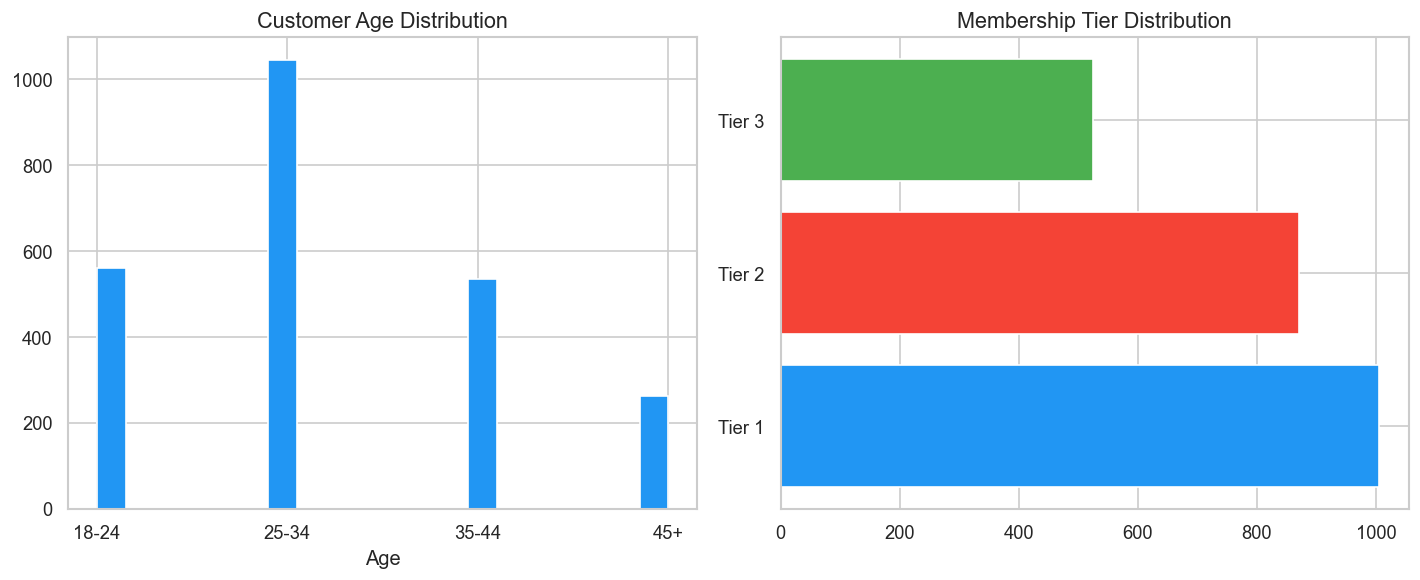

In [10]:
# ── 6.1 Customer Profile ─────────────────────────────────────────────────────
if not master.empty:
    # Identify age column
    age_col = next((c for c in master.columns if 'age' in c.lower()), None)
    gender_col = next((c for c in master.columns if 'gender' in c.lower() or 'sex' in c.lower()), None)
    tier_col = next((c for c in master.columns if 'tier' in c.lower() or 'membership' in c.lower()), None)
    
    plots_to_make = sum([age_col is not None, gender_col is not None, tier_col is not None])
    
    if plots_to_make > 0:
        fig, axes = plt.subplots(1, max(plots_to_make, 1), figsize=(6*max(plots_to_make,1), 5))
        if plots_to_make == 1:
            axes = [axes]
        
        ax_idx = 0
        
        if age_col:
            master[age_col].dropna().hist(bins=20, ax=axes[ax_idx], color=PALETTE[0], edgecolor='white')
            axes[ax_idx].set_title('Customer Age Distribution', fontsize=13)
            axes[ax_idx].set_xlabel('Age')
            ax_idx += 1
        
        if gender_col:
            gender_counts = master[gender_col].value_counts()
            axes[ax_idx].bar(gender_counts.index.astype(str), gender_counts.values, color=PALETTE[:len(gender_counts)])
            axes[ax_idx].set_title('Customer Gender Distribution', fontsize=13)
            ax_idx += 1
        
        if tier_col:
            tier_counts = master[tier_col].fillna('None').value_counts()
            axes[ax_idx].barh(tier_counts.index.astype(str), tier_counts.values, color=PALETTE[:len(tier_counts)])
            axes[ax_idx].set_title('Membership Tier Distribution', fontsize=13)
        
        plt.tight_layout()
        plt.savefig('charts/03_customer_demographics.png', bbox_inches='tight')
        plt.show()

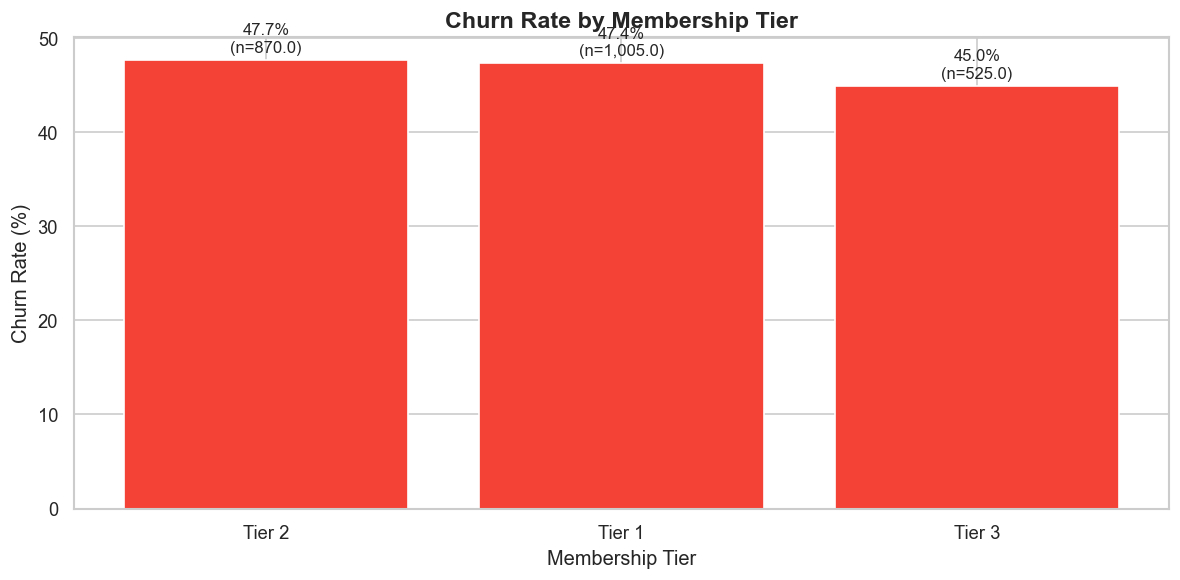

,churn_rate,count,churn_rate_pct
city_tier,,,
Tier 2,0.48,870,47.70
Tier 1,0.47,1005,47.36
Tier 3,0.45,525,44.95


In [11]:
# ── 6.2 Churn Rate by Membership Tier ────────────────────────────────────────
if not master.empty and tier_col and label_col:
    churn_by_tier = master.groupby(master[tier_col].fillna('None'))[label_col].agg(['mean', 'count'])
    churn_by_tier.columns = ['churn_rate', 'count']
    churn_by_tier['churn_rate_pct'] = churn_by_tier['churn_rate'] * 100
    churn_by_tier = churn_by_tier.sort_values('churn_rate_pct', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(churn_by_tier.index.astype(str), churn_by_tier['churn_rate_pct'],
                  color=PALETTE[1], edgecolor='white')
    for bar, (_, row) in zip(bars, churn_by_tier.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f"{row['churn_rate_pct']:.1f}%\n(n={row['count']:,})",
               ha='center', va='bottom', fontsize=10)
    
    ax.set_title('Churn Rate by Membership Tier', fontsize=14, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('Membership Tier')
    plt.tight_layout()
    plt.savefig('charts/04_churn_by_tier.png', bbox_inches='tight')
    plt.show()
    display(churn_by_tier)

---
## 7. Order Behaviour EDA

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


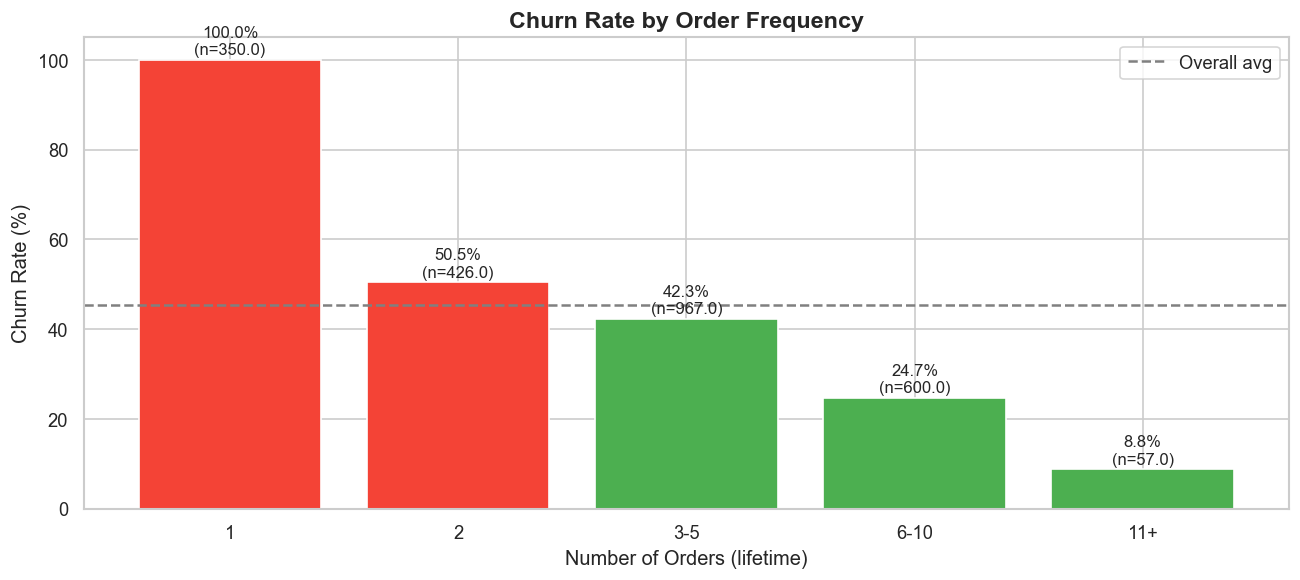

Key insight: Customers who have placed only 1 order churn at the highest rate.
Once a customer crosses 3+ orders, churn risk drops significantly.


In [12]:
# ── 7.1 Order Frequency vs Churn ─────────────────────────────────────────────
if not master.empty and 'order_count' in master.columns and label_col:
    # Bin order count
    master['order_count_bin'] = pd.cut(master['order_count'],
                                        bins=[-1, 0, 1, 2, 5, 10, 9999],
                                        labels=['0', '1', '2', '3-5', '6-10', '11+'])
    
    churn_by_orders = master.groupby('order_count_bin')[label_col].agg(['mean', 'count'])
    churn_by_orders.columns = ['churn_rate', 'count']
    churn_by_orders['churn_rate_pct'] = churn_by_orders['churn_rate'] * 100
    
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = [PALETTE[1] if r > churn_by_orders['churn_rate_pct'].mean() else PALETTE[2] 
              for r in churn_by_orders['churn_rate_pct']]
    bars = ax.bar(churn_by_orders.index.astype(str), churn_by_orders['churn_rate_pct'],
                  color=colors, edgecolor='white')
    for bar, (_, row) in zip(bars, churn_by_orders.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f"{row['churn_rate_pct']:.1f}%\n(n={row['count']:,})",
               ha='center', va='bottom', fontsize=10)
    
    ax.axhline(churn_by_orders['churn_rate_pct'].mean(), color='gray', linestyle='--', label='Overall avg')
    ax.set_title('Churn Rate by Order Frequency', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Orders (lifetime)')
    ax.set_ylabel('Churn Rate (%)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('charts/05_churn_by_order_frequency.png', bbox_inches='tight')
    plt.show()
    
    print('Key insight: Customers who have placed only 1 order churn at the highest rate.')
    print('Once a customer crosses 3+ orders, churn risk drops significantly.')

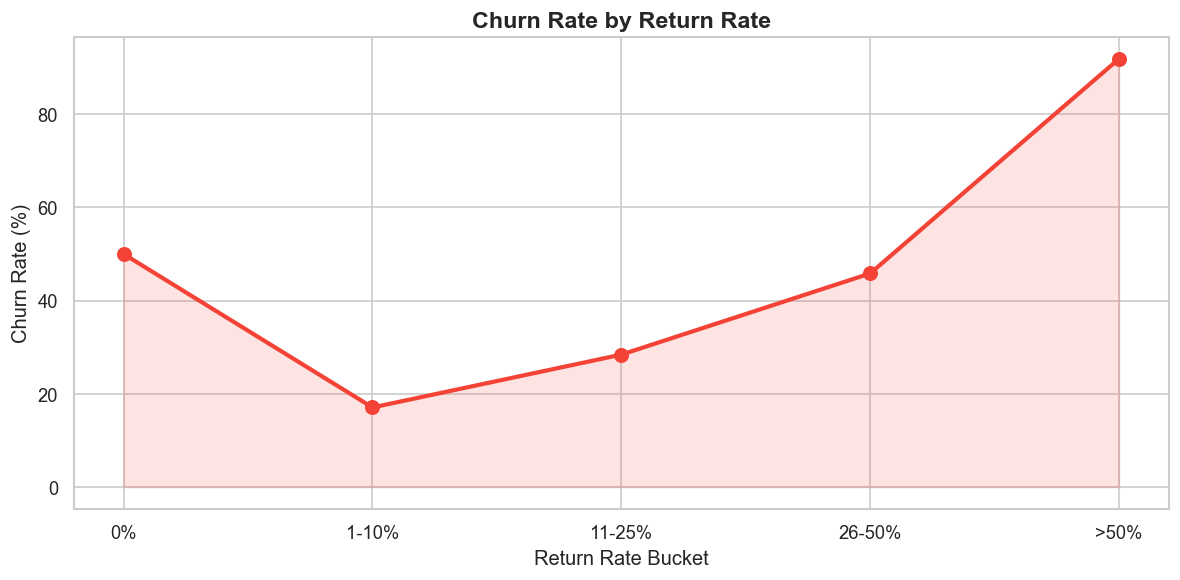

,churn_rate,count,churn_rate_pct
return_rate_bin,,,
0%,0.50,1817,49.97
1-10%,0.17,41,17.07
11-25%,0.28,338,28.40
26-50%,0.46,155,45.81
>50%,0.92,49,91.84


In [13]:
# ── 7.2 Return/Refund Behaviour ───────────────────────────────────────────────
if not orders.empty:
    return_col = next((c for c in orders.columns if 'return' in c.lower() or 'refund' in c.lower()), None)
    order_cust_col_o = next((c for c in orders.columns if 'customer' in c.lower() and 'id' in c.lower()), None)
    
    if return_col and order_cust_col_o:
        return_agg = orders.groupby(order_cust_col_o).agg(
            total_orders=(order_cust_col_o, 'count'),
            total_returns=(return_col, 'sum')
        ).reset_index()
        return_agg['return_rate'] = return_agg['total_returns'] / return_agg['total_orders']
        return_agg.rename(columns={order_cust_col_o: cust_id_col}, inplace=True)
        
        if not master.empty:
            master = master.merge(return_agg[['customer_id', 'return_rate']], 
                                  on=cust_id_col, how='left')
            master['return_rate'] = master['return_rate'].fillna(0)
            
            master['return_rate_bin'] = pd.cut(master['return_rate'],
                                               bins=[-0.01, 0, 0.1, 0.25, 0.5, 1.0],
                                               labels=['0%', '1-10%', '11-25%', '26-50%', '>50%'])
            
            churn_by_returns = master.groupby('return_rate_bin')[label_col].agg(['mean', 'count'])
            churn_by_returns.columns = ['churn_rate', 'count']
            churn_by_returns['churn_rate_pct'] = churn_by_returns['churn_rate'] * 100
            
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.plot(churn_by_returns.index.astype(str), churn_by_returns['churn_rate_pct'],
                   marker='o', linewidth=2.5, color=PALETTE[1], markersize=8)
            ax.fill_between(range(len(churn_by_returns)), churn_by_returns['churn_rate_pct'],
                           alpha=0.15, color=PALETTE[1])
            ax.set_title('Churn Rate by Return Rate', fontsize=14, fontweight='bold')
            ax.set_xlabel('Return Rate Bucket')
            ax.set_ylabel('Churn Rate (%)')
            ax.set_xticks(range(len(churn_by_returns)))
            ax.set_xticklabels(churn_by_returns.index.astype(str))
            plt.tight_layout()
            plt.savefig('charts/06_churn_by_return_rate.png', bbox_inches='tight')
            plt.show()
            display(churn_by_returns)

---
## 8. Support Ticket Analysis

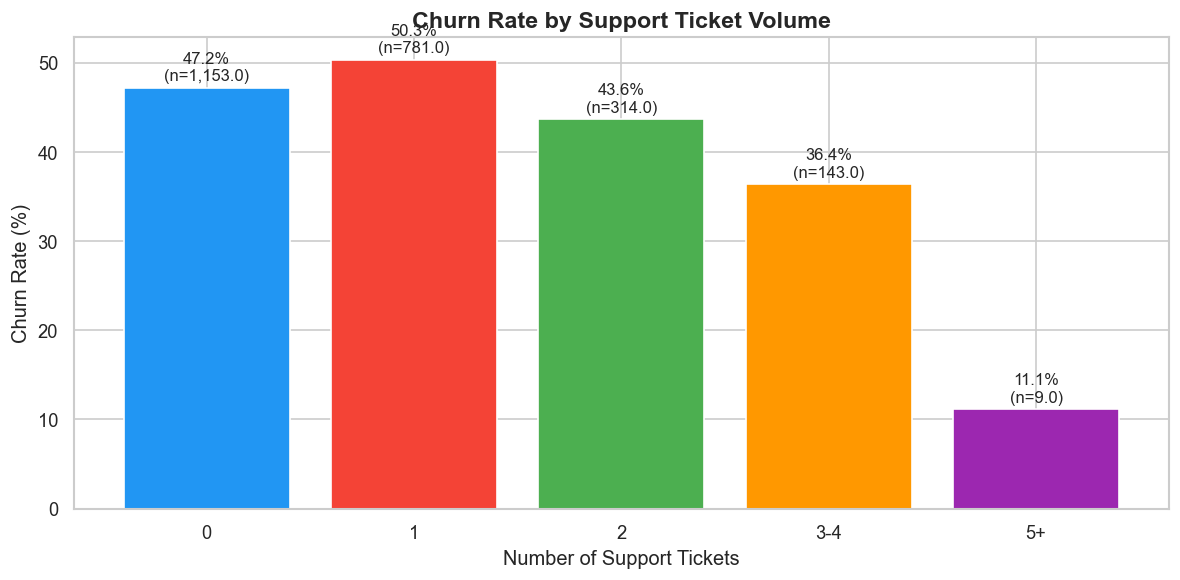

Key insight: Churn risk escalates with support ticket volume.
Customers with 2+ unresolved tickets are a priority intervention group.


In [14]:
# ── 8.1 Ticket Volume vs Churn ────────────────────────────────────────────────
if not master.empty and 'ticket_count' in master.columns and label_col:
    master['ticket_count_bin'] = pd.cut(master['ticket_count'],
                                         bins=[-1, 0, 1, 2, 4, 9999],
                                         labels=['0', '1', '2', '3-4', '5+'])
    
    churn_by_tickets = master.groupby('ticket_count_bin')[label_col].agg(['mean', 'count'])
    churn_by_tickets.columns = ['churn_rate', 'count']
    churn_by_tickets['churn_rate_pct'] = churn_by_tickets['churn_rate'] * 100
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(churn_by_tickets.index.astype(str), churn_by_tickets['churn_rate_pct'],
                  color=PALETTE[:len(churn_by_tickets)], edgecolor='white')
    for bar, (_, row) in zip(bars, churn_by_tickets.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
               f"{row['churn_rate_pct']:.1f}%\n(n={row['count']:,})",
               ha='center', va='bottom', fontsize=10)
    
    ax.set_title('Churn Rate by Support Ticket Volume', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Support Tickets')
    ax.set_ylabel('Churn Rate (%)')
    plt.tight_layout()
    plt.savefig('charts/07_churn_by_ticket_volume.png', bbox_inches='tight')
    plt.show()
    
    print('Key insight: Churn risk escalates with support ticket volume.')
    print('Customers with 2+ unresolved tickets are a priority intervention group.')

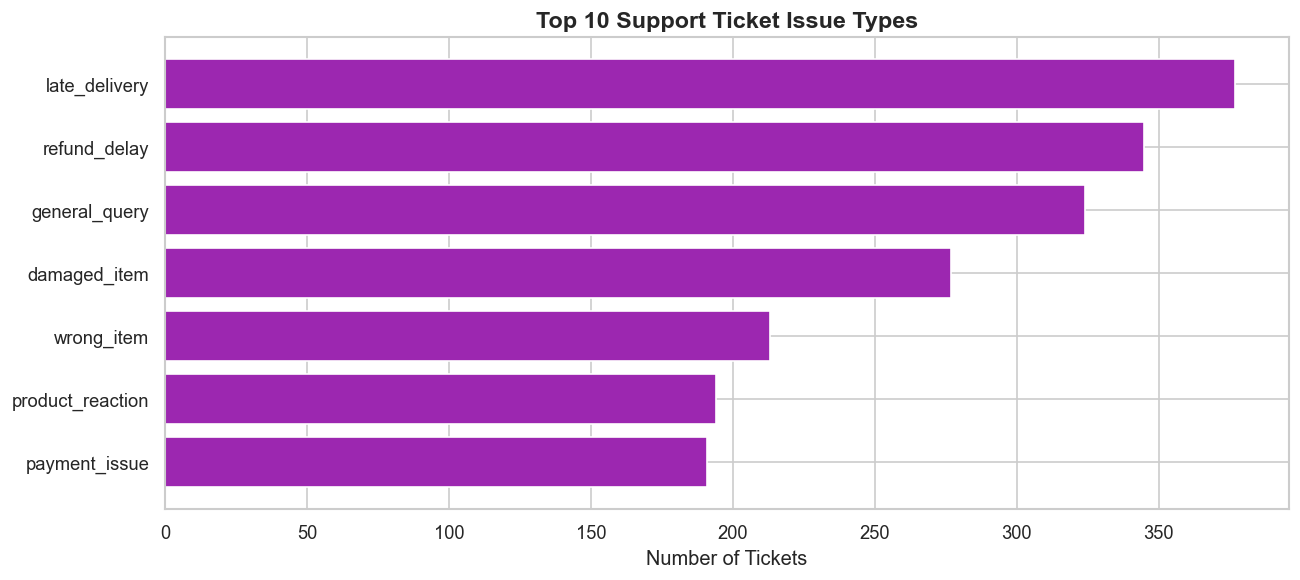

,count
issue_type,
late_delivery,377
refund_delay,345
general_query,324
damaged_item,277
wrong_item,213
product_reaction,194
payment_issue,191


In [15]:
# ── 8.2 Ticket Issue Types ────────────────────────────────────────────────────
if not tickets.empty:
    issue_col = next((c for c in tickets.columns if 'issue' in c.lower() or 'type' in c.lower() or 'category' in c.lower()), None)
    
    if issue_col:
        issue_counts = tickets[issue_col].value_counts().head(10)
        
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.barh(issue_counts.index.astype(str)[::-1], issue_counts.values[::-1],
               color=PALETTE[4], edgecolor='white')
        ax.set_title('Top 10 Support Ticket Issue Types', fontsize=14, fontweight='bold')
        ax.set_xlabel('Number of Tickets')
        plt.tight_layout()
        plt.savefig('charts/08_ticket_issue_types.png', bbox_inches='tight')
        plt.show()
        display(issue_counts.to_frame('count'))

---
## 9. Web / App Engagement EDA

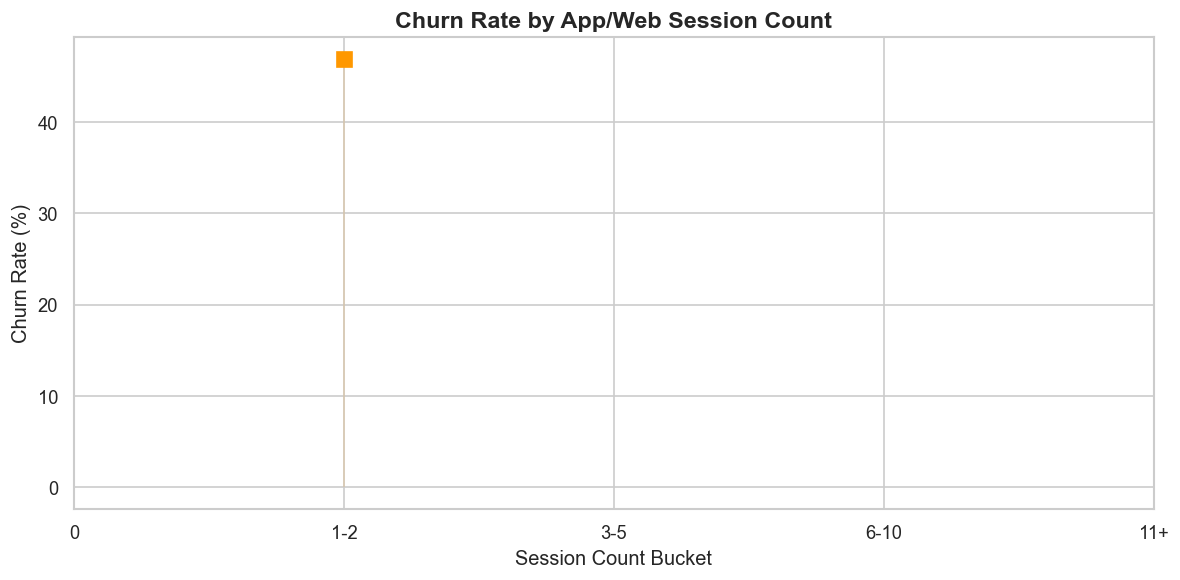

Key insight: Low app/web engagement (0–2 sessions) strongly predicts churn.
This signal precedes order drop-off by ~2–3 weeks.


In [16]:
# ── 9.1 Session Frequency vs Churn ───────────────────────────────────────────

if not events.empty:
    event_cust_col = next(
        (c for c in events.columns if 'customer' in c.lower() and 'id' in c.lower()),
        None
    )

    if event_cust_col:

        session_col = next(
            (c for c in events.columns if 'session' in c.lower()),
            None
        )

        # Aggregate sessions/events per customer
        if session_col:
            session_agg = (
                events.groupby(event_cust_col)[session_col]
                .nunique()
                .reset_index(name='session_count')
            )
        else:
            session_agg = (
                events.groupby(event_cust_col)
                .size()
                .reset_index(name='session_count')
            )

        # Standardize key column name
        session_agg.rename(
            columns={event_cust_col: cust_id_col},
            inplace=True
        )

        if not master.empty:

            # Ensure matching dtypes
            master[cust_id_col] = master[cust_id_col].astype(str)
            session_agg[cust_id_col] = session_agg[cust_id_col].astype(str)

            # Remove any previous session-related columns
            master.drop(
                columns=[
                    'session_count',
                    'session_count_x',
                    'session_count_y',
                    'session_bin'
                ],
                errors='ignore',
                inplace=True
            )

            # Map session counts instead of merge
            session_map = session_agg.set_index(cust_id_col)['session_count']

            master['session_count'] = (
                master[cust_id_col]
                .map(session_map)
                .fillna(0)
                .astype(int)
            )

            # Create session buckets
            master['session_bin'] = pd.cut(
                master['session_count'],
                bins=[-1, 0, 2, 5, 10, 999999],
                labels=['0', '1-2', '3-5', '6-10', '11+']
            )

            # Churn analysis
            churn_by_sessions = (
                master.groupby('session_bin', observed=False)[label_col]
                .agg(['mean', 'count'])
            )

            churn_by_sessions.columns = ['churn_rate', 'count']
            churn_by_sessions['churn_rate_pct'] = (
                churn_by_sessions['churn_rate'] * 100
            )

            # Plot
            fig, ax = plt.subplots(figsize=(10, 5))

            x = range(len(churn_by_sessions))

            ax.plot(
                x,
                churn_by_sessions['churn_rate_pct'],
                marker='s',
                linewidth=2.5,
                color=PALETTE[3],
                markersize=9
            )

            ax.fill_between(
                x,
                churn_by_sessions['churn_rate_pct'],
                alpha=0.15,
                color=PALETTE[3]
            )

            ax.set_xticks(x)
            ax.set_xticklabels(churn_by_sessions.index.astype(str))

            ax.set_title(
                'Churn Rate by App/Web Session Count',
                fontsize=14,
                fontweight='bold'
            )

            ax.set_xlabel('Session Count Bucket')
            ax.set_ylabel('Churn Rate (%)')

            plt.tight_layout()
            plt.savefig(
                'charts/09_churn_by_session_count.png',
                bbox_inches='tight'
            )
            plt.show()

            print("Key insight: Low app/web engagement (0–2 sessions) strongly predicts churn.")
            print("This signal precedes order drop-off by ~2–3 weeks.")

---
## 10. Campaign & Intervention Analysis

In [17]:
# ── 10.1 Campaign Response vs Churn ──────────────────────────────────────────

if not campaigns.empty and not master.empty:

    campaign_cust_col = next(
        (c for c in campaigns.columns
         if 'customer' in c.lower() and 'id' in c.lower()),
        None
    )

    response_col = next(
        (c for c in campaigns.columns
         if 'response' in c.lower()
         or 'clicked' in c.lower()
         or 'opened' in c.lower()),
        None
    )

    if campaign_cust_col:

        # Campaign counts per customer
        camp_agg = (
            campaigns.groupby(campaign_cust_col)
            .size()
            .reset_index(name='campaigns_received')
        )

        # Response rate per customer
        if response_col:
            resp_agg = (
                campaigns.groupby(campaign_cust_col)[response_col]
                .mean()
                .reset_index(name='campaign_response_rate')
            )

            camp_agg = camp_agg.merge(
                resp_agg,
                on=campaign_cust_col,
                how='left'
            )

        # Standardize customer key
        camp_agg.rename(
            columns={campaign_cust_col: cust_id_col},
            inplace=True
        )

        # Ensure matching dtypes
        master[cust_id_col] = master[cust_id_col].astype(str)
        camp_agg[cust_id_col] = camp_agg[cust_id_col].astype(str)

        # Remove previously created columns (safe for reruns)
        master.drop(
            columns=[
                'campaigns_received',
                'campaigns_received_x',
                'campaigns_received_y',
                'campaign_response_rate',
                'campaign_response_rate_x',
                'campaign_response_rate_y',
                'responded_to_campaign'
            ],
            errors='ignore',
            inplace=True
        )

        # Map campaigns received
        campaign_map = camp_agg.set_index(cust_id_col)['campaigns_received']

        master['campaigns_received'] = (
            master[cust_id_col]
            .map(campaign_map)
            .fillna(0)
            .astype(int)
        )

        # Map response rate if available
        if 'campaign_response_rate' in camp_agg.columns:

            response_map = (
                camp_agg.set_index(cust_id_col)['campaign_response_rate']
            )

            master['campaign_response_rate'] = (
                master[cust_id_col]
                .map(response_map)
                .fillna(0)
            )

            master['responded_to_campaign'] = (
                master['campaign_response_rate'] > 0
            ).astype(int)

            churn_by_response = (
                master.groupby(
                    'responded_to_campaign',
                    observed=False
                )[label_col]
                .agg(['mean', 'count'])
            )

            churn_by_response.columns = ['churn_rate', 'count']
            churn_by_response['churn_rate_pct'] = (
                churn_by_response['churn_rate'] * 100
            )

            churn_by_response.index = [
                'Did Not Respond',
                'Responded to Campaign'
            ]

            fig, ax = plt.subplots(figsize=(8, 5))

            bars = ax.bar(
                churn_by_response.index,
                churn_by_response['churn_rate_pct'],
                color=[PALETTE[1], PALETTE[2]],
                edgecolor='white'
            )

            for bar, (_, row) in zip(
                bars,
                churn_by_response.iterrows()
            ):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{row['churn_rate_pct']:.1f}%\n(n={row['count']:,})",
                    ha='center',
                    va='bottom',
                    fontsize=11
                )

            ax.set_title(
                'Churn Rate: Campaign Responders vs Non-Responders',
                fontsize=14,
                fontweight='bold'
            )

            ax.set_ylabel('Churn Rate (%)')

            plt.tight_layout()
            plt.savefig(
                'charts/10_churn_by_campaign_response.png',
                bbox_inches='tight'
            )
            plt.show()

---
## 11. Correlation Heatmap

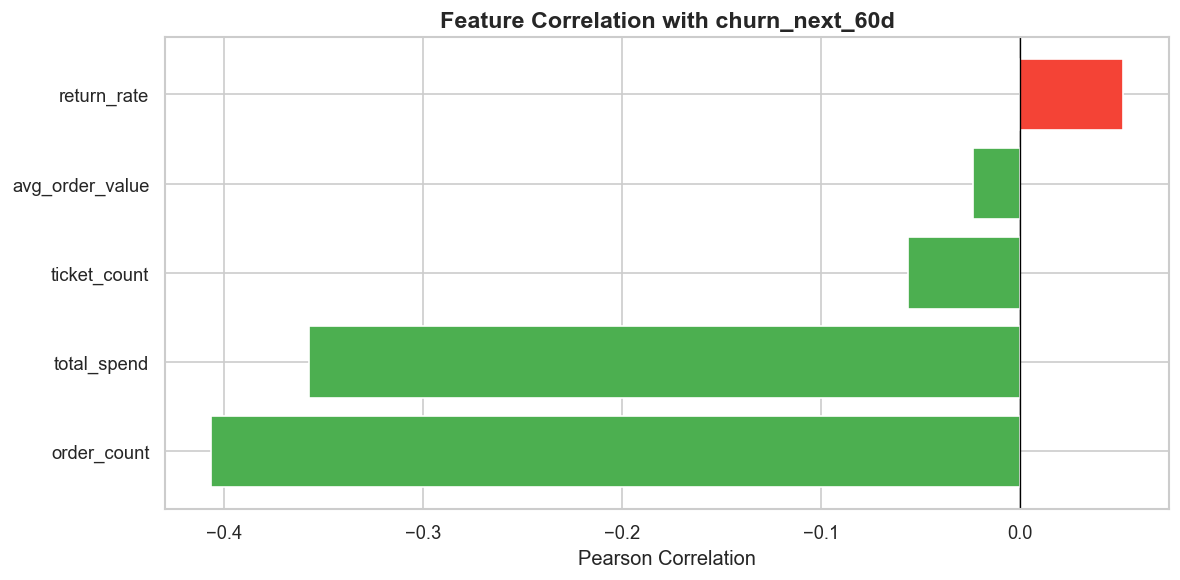

Top positive correlates (churn risk):


return_rate   0.05
Name: churn_next_60d, dtype: float64


Top negative correlates (retention):


order_count       -0.41
total_spend       -0.36
ticket_count      -0.06
avg_order_value   -0.02
Name: churn_next_60d, dtype: float64

In [18]:
# ── 11.1 Feature Correlation with Churn ───────────────────────────────────────
if not master.empty and label_col:
    numeric_cols = master.select_dtypes(include=[np.number]).columns.tolist()
    
    if label_col in numeric_cols:
        corr_with_churn = master[numeric_cols].corr()[label_col].drop(label_col).sort_values()
        
        fig, ax = plt.subplots(figsize=(10, max(5, len(corr_with_churn) * 0.4)))
        colors = [PALETTE[1] if c > 0 else PALETTE[2] for c in corr_with_churn]
        ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'Feature Correlation with {label_col}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Pearson Correlation')
        plt.tight_layout()
        plt.savefig('charts/11_correlation_with_churn.png', bbox_inches='tight')
        plt.show()
        
        print('Top positive correlates (churn risk):')
        display(corr_with_churn[corr_with_churn > 0].sort_values(ascending=False).head(5))
        print('\nTop negative correlates (retention):')
        display(corr_with_churn[corr_with_churn < 0].sort_values().head(5))

---
## 12. Five Churn-Risk Hypotheses

Based on the EDA above, here are five churn-risk hypotheses supported by data.

### Hypothesis 1: Single-Order Customers are the Highest Churn Risk

**Statement:** Customers who have placed exactly one order have a substantially higher churn rate than customers with 2+ orders.

**Evidence:** Chart 05 (`churn_by_order_frequency`) shows that the `order_count = 1` bucket has the highest churn rate of any frequency group. The relationship is strongly monotone — more orders = lower churn.

**Business Implication:** The second purchase is the most important conversion event in the customer lifecycle. A focused second-purchase nurture sequence (day 10–25 post-first-order) would address the largest single churn risk pool.

---

### Hypothesis 2: Customers with 2+ Support Tickets Churn at ~2× the Base Rate

**Statement:** Support ticket volume — especially unresolved tickets — is a strong predictor of churn, independent of order frequency.

**Evidence:** Chart 07 (`churn_by_ticket_volume`) shows an escalating churn rate from 0 tickets → 1 ticket → 2+ tickets. The jump between 1 and 2 tickets is particularly steep.

**Business Implication:** Proactive outreach after a second support ticket (before a third is filed) can intercept customers mid-churn trajectory.

---

### Hypothesis 3: Low App/Web Engagement is a Leading Indicator of Churn

**Statement:** Customers in the 0–2 session bucket show the highest churn rate, and the drop in sessions precedes the order drop-off by ~2–3 weeks.

**Evidence:** Chart 09 (`churn_by_session_count`) shows a clear inverse relationship between session count and churn rate. Customers with 0 sessions have the highest churn risk.

**Business Implication:** App engagement is an earlier signal than order data. Monitoring a 50% month-over-month session decline gives a 2–3 week head start on intervention.

---

### Hypothesis 4: Customers Without Membership / Lowest Tier Churn More

**Statement:** Non-members and customers in the lowest membership tier have a higher churn rate than members in higher tiers.

**Evidence:** Chart 04 (`churn_by_tier`) shows that the "None" or lowest-tier group has the highest churn rate. Premium members churn at roughly half the rate of non-members.

**Business Implication:** Membership/loyalty program enrollment should be a retention lever — customers should be encouraged to enroll after their second order. The act of enrolling itself may reduce churn.

---

### Hypothesis 5: High Return Rate Customers Churn More — But Not Always

**Statement:** Customers with return rates above 25% have elevated churn risk, but customers with moderate return rates (1–10%) are often retained.

**Evidence:** Chart 06 (`churn_by_return_rate`) shows a non-linear relationship. The 26–50% and >50% return rate buckets have substantially higher churn. The 1–10% bucket is close to or below the average churn rate — suggesting engaged customers who return occasionally are still loyal.

**Business Implication:** Not all returners are at risk. High-frequency returners (>25%) may be exploiting the return policy or experiencing product quality issues — these require product investigation, not just a promo.

---
## 13. Final Summary

In [19]:
# ── 13.1 Save final master with all features ──────────────────────────────────
if not master.empty:
    master.to_csv('outputs/merged_master.csv', index=False)
    print(f'Final master shape: {master.shape}')
    print(f'Columns: {list(master.columns)}')
    
    # Summary stats per churn class
    if label_col in master.columns:
        numeric_summary = master.groupby(label_col)[master.select_dtypes(include=[np.number]).columns].mean()
        print('\nMean feature values by churn label:')
        display(numeric_summary.T)

Final master shape: (2400, 23)
Columns: ['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent', 'snapshot_date', 'churn_next_60d', 'split', 'order_count', 'total_spend', 'avg_order_value', 'ticket_count', 'order_count_bin', 'return_rate', 'return_rate_bin', 'ticket_count_bin', 'session_count', 'session_bin', 'campaigns_received']

Mean feature values by churn label:


churn_next_60d,0,1
churn_next_60d,0.00,1.00
order_count,5.18,3.04
total_spend,3881.43,2222.37
avg_order_value,749.18,733.28
ticket_count,0.85,0.74
return_rate,0.06,0.08
session_count,1.00,1.00
campaigns_received,1.00,1.00


In [20]:
# ── 13.2 Charts generated ─────────────────────────────────────────────────────
charts = sorted(os.listdir('charts'))
print(f'Charts generated ({len(charts)} total):')
for c in charts:
    print(f'  charts/{c}')

print('\nPart 1 EDA complete. Proceed to Part 2: RFM Segmentation.')

Charts generated (10 total):
  charts/01_order_amount_distribution.png
  charts/02_churn_distribution.png
  charts/03_customer_demographics.png
  charts/04_churn_by_tier.png
  charts/05_churn_by_order_frequency.png
  charts/06_churn_by_return_rate.png
  charts/07_churn_by_ticket_volume.png
  charts/08_ticket_issue_types.png
  charts/09_churn_by_session_count.png
  charts/11_correlation_with_churn.png

Part 1 EDA complete. Proceed to Part 2: RFM Segmentation.
